In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
from ChildProject.projects import ChildProject
from ChildProject.annotations import AnnotationManager

DATA_PATH = Path.cwd().parent.parent / 'data' 
columns = ['recording_filename', '5s_CTC', '1s_CTC', 'voc_chi', 'voc_dur_chi']

# Read measures
aclew_measures = pd.read_csv(DATA_PATH / 'measures' / 'aclew_measures_chunks.csv').fillna(0)
lena_measures = pd.read_csv(DATA_PATH / 'measures' / 'lena_measures_chunks.csv').fillna(0)
human_measures = pd.read_csv(DATA_PATH / 'measures' / 'human_measures_chunks.csv').fillna(0)

# Read metadata
children = pd.read_csv(DATA_PATH / 'metadata/children.csv')
recordings = pd.read_csv(DATA_PATH / 'metadata/recordings.csv')
recordings_data = recordings.merge(children, on='child_id')[['group_id', 'recording_filename']]
aclew_measures = aclew_measures.merge(recordings_data, how='left', on='recording_filename')
lena_measures = lena_measures.merge(recordings_data, how='left', on='recording_filename')
human_measures = human_measures.merge(recordings_data, how='left', on='recording_filename')


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def analyze_time_intervals(auto_data, manual_data, measure, base_interval=2, max_interval=30):
    nb_clips = len(auto_data)
    auto_data_tmp = auto_data.sort_values(by=['recording_filename', 'segment_onset']).copy()
    manual_data_tmp = manual_data.sort_values(by=['recording_filename', 'segment_onset']).copy()
    out = []
    clip_dur = 2
    
    # First iteration with original 2-min clips
    auto_measures = auto_data_tmp[measure]
    manual_measures = manual_data_tmp[measure]
    out.append({'pearson': stats.pearsonr(auto_measures, manual_measures)[0], 'duration': clip_dur, 'nb_clips': len(auto_data)})
    while clip_dur < max_interval:
        # Increase duration by 2 minutes
        clip_dur += 2
        
        # Create new dataframes for the current duration
        auto_combined = []
        manual_combined = []
        
        # Group by recording filename
        for filename, group in auto_data.groupby('recording_filename'):
            # Sort by segment_onset within each group
            group = group.sort_values('segment_onset')
            
            # Number of original 2-min clips to combine
            n_clips_to_combine = clip_dur // 2
            
            # Process each group in chunks of n_clips_to_combine
            for i in range(0, len(group), n_clips_to_combine):
                chunk = group.iloc[i:i+n_clips_to_combine]
                
                # Only use complete chunks matching our target duration
                if len(chunk) == n_clips_to_combine:
                    combined_row = chunk.iloc[0].copy()
                    combined_row['segment_offset'] = chunk.iloc[-1]['segment_offset']
                    combined_row[measure] = chunk[measure].sum()
                    auto_combined.append(combined_row)
        
        # Do the same for manual data
        for filename, group in manual_data.groupby('recording_filename'):
            group = group.sort_values('segment_onset')
            n_clips_to_combine = clip_dur // 2
            
            for i in range(0, len(group), n_clips_to_combine):
                chunk = group.iloc[i:i+n_clips_to_combine]
                if len(chunk) == n_clips_to_combine:
                    combined_row = chunk.iloc[0].copy()
                    combined_row['segment_offset'] = chunk.iloc[-1]['segment_offset']
                    combined_row[measure] = chunk[measure].sum()
                    manual_combined.append(combined_row)
        # Convert to dataframes
        auto_combined_df = pd.DataFrame(auto_combined)
        manual_combined_df = pd.DataFrame(manual_combined)

        # Calculate correlation if we have data
        if len(auto_combined_df) > 0 and len(manual_combined_df) > 0:
            auto_measures = auto_combined_df[measure]
            manual_measures = manual_combined_df[measure]
            out.append({'pearson': stats.pearsonr(auto_measures, manual_measures)[0], 'duration': clip_dur, 'nb_clips': len(auto_combined_df)})
            
            print(f"\n{clip_dur}-minute clips ({len(auto_combined_df)} clips):")
    
    return pd.DataFrame(out)

# For LENA data
results_lena = analyze_time_intervals(lena_measures, human_measures, 
                                   measure='5s_CTC',
                                   base_interval=2,
                                   max_interval=30)

# For ACLEW data
results_aclew = analyze_time_intervals(aclew_measures, human_measures, 
                                    measure='5s_CTC',
                                    base_interval=2,
                                    max_interval=30)


results_aclew


4-minute clips (350 clips):

6-minute clips (250 clips):

8-minute clips (150 clips):

10-minute clips (150 clips):

12-minute clips (100 clips):

14-minute clips (100 clips):

16-minute clips (50 clips):

18-minute clips (50 clips):

20-minute clips (50 clips):

22-minute clips (50 clips):

24-minute clips (50 clips):

26-minute clips (50 clips):

28-minute clips (50 clips):

30-minute clips (50 clips):

4-minute clips (350 clips):

6-minute clips (250 clips):

8-minute clips (150 clips):

10-minute clips (150 clips):

12-minute clips (100 clips):

14-minute clips (100 clips):

16-minute clips (50 clips):

18-minute clips (50 clips):

20-minute clips (50 clips):

22-minute clips (50 clips):

24-minute clips (50 clips):

26-minute clips (50 clips):

28-minute clips (50 clips):

30-minute clips (50 clips):


,pearson,duration,nb_clips
0,0.835966,2,750
1,0.855197,4,350
2,0.852322,6,250
3,0.868905,8,150
4,0.887041,10,150
5,0.875974,12,100
6,0.902185,14,100
7,0.889447,16,50
8,0.883515,18,50
9,0.894727,20,50


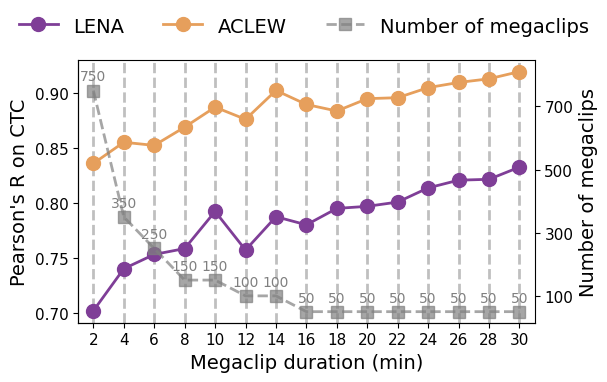

In [3]:
import matplotlib

matplotlib.rcParams.update({'font.size': 14, 'legend.handleheight': 1, 'hatch.linewidth': 1.0,
                          'lines.markersize': 10, 'lines.linewidth': 2, 'errorbar.capsize': 5,
                           'xtick.labelsize': 11, 'ytick.labelsize': 11})

def plot_results(results_lena, results_aclew, extra_y='', metric='pearson'):
    metric_col = f'{metric}'
    lena_color = '#7F3E97'
    aclew_color = '#E69F5C'
    cm = 1/2.54
    fig, ax = plt.subplots(figsize=(16*cm, 10*cm))
    
    # Main lines for Pearson's R
    ax.plot(results_lena['duration'], results_lena[metric_col], 'o-', color=lena_color, linewidth=2, label=f'LENA')
    ax.plot(results_lena['duration'], results_aclew[metric_col], 'o-', color=aclew_color, linewidth=2, label=f'ACLEW')
    
    # Create a secondary y-axis for number of clips
    ax2 = ax.twinx()
    ax2.plot(results_lena['duration'], results_lena['nb_clips'], 's--', color='gray', alpha=0.7, markersize=8, label='Number of megaclips')
    ax2.set_ylabel('Number of megaclips')
    
    # Add clip count labels above the points
    for i, row in results_lena.iterrows():
        ax2.annotate(f"{int(row['nb_clips'])}", 
                     xy=(row['duration'], 10+row['nb_clips']),
                     xytext=(0, 5),
                     textcoords='offset points',
                     ha='center',
                     fontsize=10,
                     color='gray')
    
    # Main axis settings
    ax.set_xlabel('Megaclip duration (min)')
    ax.set_ylabel(f"Pearson's R{extra_y}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(np.arange(2, 32, 2))
    ax.set_xlim(2, 30)
    min_y, max_y = ax2.get_ylim()
    ax2.set_ylim(min_y, max_y*1.08)
    ax2.set_yticks([700, 500, 300, 100])
    # Add vertical dashed lines every 2 minutes
    for t in range(2, 32, 2):
        ax.axvline(x=t, color='gray', linestyle='--', alpha=0.5, zorder=-5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(1,31)
    # Create a combined legend and place it above the graph
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    fig.legend(lines1 + lines2, labels1 + labels2, 
               loc='upper center', 
               bbox_to_anchor=(0.5, 1.0),
               ncol=3,  # Display legend items in 3 columns
               frameon=False)  # Remove the legend frame
    
    # Adjust the top margin to make room for the legend
    plt.subplots_adjust(top=0.85)
    
    plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust the rect parameter to make room for the legend
    plt.savefig('/home/engaclew/neurogen/figures/pearson_duration_lena_aclew.png', dpi=300)
    plt.show()
# Plot results
metric='pearson'
plot_results(results_lena, results_aclew, extra_y=' on CTC', metric=metric)